In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from mlxtend.evaluate.time_series import (
    GroupTimeSeriesSplit,
    plot_splits,
    print_cv_info,
    print_split_info,
)

In [2]:
# --- ГЛОБАЛЬНЫЕ ПАРАМЕТРЫ ---
MONTH_COL = 'DATE'
TARGET_COL = 'Value_NextMonth'
FEATURE_COL = 'Value'
OOT_PERIODS = 60 # 5 лет

In [3]:
df = pd.read_csv('data/ds_Electric.csv')

In [4]:
df.columns = [MONTH_COL, FEATURE_COL]
df[MONTH_COL] = pd.to_datetime(df[MONTH_COL])

In [5]:
df.sort_values(MONTH_COL, inplace=True)
df.reset_index(drop=True, inplace=True)

In [6]:
# --- напишите ваш код здесь ---
# Задача 1: Создайте признаки 'month_num' и 'year'
df['month_num'] = df[MONTH_COL].dt.month
df['year'] = df[MONTH_COL].dt.year

# Задача 2: Создайте целевую переменную TARGET_COL (сдвиг -1) и удалите NaN
df[TARGET_COL] = df[FEATURE_COL].shift(-1)
df = df.dropna(subset=[TARGET_COL])

# Задача 3: Разделите df на df_train_val и df_oot_base
df_train_val = df.iloc[:-OOT_PERIODS].copy()
df_oot_base = df.iloc[-OOT_PERIODS:].copy()

# Задача 4: Создайте колонку 'group_id' в df_train_val равную 'year'
df_train_val['group_id'] = df_train_val['year']

In [7]:
print(f"Размер Обучение/Валидация: {df_train_val.shape[0]}")
print(f"Размер OOT-набора: {df_oot_base.shape[0]}")
print(f"Первые строки df_train_val:\n{df_train_val.head(3).to_string()}")

Размер Обучение/Валидация: 336
Размер OOT-набора: 60
Первые строки df_train_val:
        DATE    Value  month_num  year  Value_NextMonth  group_id
0 1985-01-01  72.5052          1  1985          70.6720      1985
1 1985-02-01  70.6720          2  1985          62.4502      1985
2 1985-03-01  62.4502          3  1985          57.4714      1985


### Задача 1. Лагированные признаки и скользящие окна

In [8]:
# --- Создайте временные признаки ---

df_train_val.set_index(MONTH_COL, inplace=True)

# 1. Lag_1_Value
df_train_val['Lag_1_Value'] = df_train_val['Value'].shift()

# 2. Rolling_Mean_Value_3
df_train_val['Rolling_Mean_Value_3'] = df_train_val['Value'].rolling(window=3).mean().shift(1)

# 3. Expanding_Mean_Value
df_train_val['Expanding_Mean_Value'] = df_train_val['Value'].expanding().mean().shift(1)

X_train_val = df_train_val.drop([TARGET_COL], axis=1)
y_train_val = df_train_val[TARGET_COL]

# --- Проверка ---
print(df_train_val.head())

              Value  month_num  year  Value_NextMonth  group_id  Lag_1_Value  \
DATE                                                                           
1985-01-01  72.5052          1  1985          70.6720      1985          NaN   
1985-02-01  70.6720          2  1985          62.4502      1985      72.5052   
1985-03-01  62.4502          3  1985          57.4714      1985      70.6720   
1985-04-01  57.4714          4  1985          55.3151      1985      62.4502   
1985-05-01  55.3151          5  1985          58.0904      1985      57.4714   

            Rolling_Mean_Value_3  Expanding_Mean_Value  
DATE                                                    
1985-01-01                   NaN                   NaN  
1985-02-01                   NaN             72.505200  
1985-03-01                   NaN             71.588600  
1985-04-01             68.542467             68.542467  
1985-05-01             63.531200             65.774700  


### Задача 2. Кумулятивные и сезонные агрегаты

In [9]:
# 1. Годовое среднее (Yearly_Mean_Value)
# Вычислите среднее по году, используя FEATURE_COL = 'Value'
yearly_mean = df_train_val.groupby('year')[FEATURE_COL].mean()

# Сдвиньте по годам на 1, используя среднее предыдущего года
yearly_mean_shifted = yearly_mean.shift(1)

# Присваиваем обратно к строкам через колонку 'year'
df_train_val['Yearly_Mean_Value'] = df_train_val['year'].map(yearly_mean_shifted)

# 2. Сезонные признаки (month_num_cos, month_num_sin)
month_num = df_train_val['month_num']

# 2. Сезонные признаки (month_num_cos, month_num_sin)
# Используйте df_train_val['month_num']
df_train_val['month_num_cos'] = np.cos(2 * np.pi * df_train_val['month_num'] / 12)
df_train_val['month_num_sin'] = np.sin(2 * np.pi * df_train_val['month_num'] / 12)

# --- Проверка ---
print(df_train_val[['year', 'month_num', FEATURE_COL, 'Yearly_Mean_Value', 'month_num_cos']].head(15).to_string())

            year  month_num    Value  Yearly_Mean_Value  month_num_cos
DATE                                                                  
1985-01-01  1985          1  72.5052                NaN   8.660254e-01
1985-02-01  1985          2  70.6720                NaN   5.000000e-01
1985-03-01  1985          3  62.4502                NaN   6.123234e-17
1985-04-01  1985          4  57.4714                NaN  -5.000000e-01
1985-05-01  1985          5  55.3151                NaN  -8.660254e-01
1985-06-01  1985          6  58.0904                NaN  -1.000000e+00
1985-07-01  1985          7  62.6202                NaN  -8.660254e-01
1985-08-01  1985          8  63.2485                NaN  -5.000000e-01
1985-09-01  1985          9  60.5846                NaN  -1.836970e-16
1985-10-01  1985         10  56.3154                NaN   5.000000e-01
1985-11-01  1985         11  58.0005                NaN   8.660254e-01
1985-12-01  1985         12  68.7145                NaN   1.000000e+00
1986-0

In [10]:
# --- 1. ФУНКЦИЯ ДЛЯ АГРЕГАТНЫХ ПРИЗНАКОВ ---
def create_time_series_features(df):
    """Рассчитывает лагированные, агрегатные признаки и годовое среднее, соблюдая хронологию."""
    
    # 1. Лагированные признаки и скользящие окна (t-n)
    df['Lag_1_Value'] = df[FEATURE_COL].shift(1)
    df['Rolling_Mean_Value_3'] = df[FEATURE_COL].rolling(window=3, min_periods=1).mean().shift(1)
    df['Expanding_Mean_Value'] = df[FEATURE_COL].expanding().mean().shift(1)

    # 2. Годовые агрегаты (для захвата долгосрочного тренда)
    # Вычисляем среднее по году
    yearly_mean = df_train_val.groupby('year')[FEATURE_COL].mean()

    # Сдвигаем по годам на 1 (используем среднее предыдущего года)
    yearly_mean_shifted = yearly_mean.shift(1)

    # Присваиваем обратно к строкам через колонку 'year'
    df_train_val['Yearly_Mean_Value'] = df_train_val['year'].map(yearly_mean_shifted)

    # 3. Циклическое кодирование сезонности
    if 'month_num' in df.columns:
        df['month_num_cos'] = np.cos(2 * np.pi * df['month_num'] / 12)
        df['month_num_sin'] = np.sin(2 * np.pi * df['month_num'] / 12)

    return df 

### Задача 3. Настройка GroupTimeSeriesSplit

In [11]:
# --- ГЛОБАЛЬНЫЕ ПАРАМЕТРЫ ---
N_SPLITS_DESIRED = 5 # Ваш код
TEST_SIZE_GROUPS = 3 # Ваш код

In [12]:
# 1. Сформируйте словарь аргументов для GTS
cv_args = {
    'test_size': TEST_SIZE_GROUPS,
    'n_splits': N_SPLITS_DESIRED,
    'gap_size': 1,
    'shift_size': 1,
    'window_type': 'rolling'
}

# 2. Инициализируйте GroupTimeSeriesSplit, используя словарь cv_args
gts = GroupTimeSeriesSplit(**cv_args)

# --- Проверка ---
print(f"GTS инициализирован: {gts.n_splits} фолдов, тестовое окно = {gts.test_size} года.")
print("\nМетодологическая справка:")
print(f"Тестовое окно = {TEST_SIZE_GROUPS} года, то есть {TEST_SIZE_GROUPS * 12} месяцев.")

GTS инициализирован: 5 фолдов, тестовое окно = 3 года.

Методологическая справка:
Тестовое окно = 3 года, то есть 36 месяцев.


### Задачи 4. Обучение модели

In [13]:
# Инициализируйте модель
rf_model = RandomForestRegressor(
    n_estimators=10,
    random_state=42,
    n_jobs=-1
)

# Создание простого пайплайна (без масштабирования)
pipeline = Pipeline(steps=[
    ('rf_regressor', rf_model)
])

In [14]:
cv_metrics = {'MAE': [], 'RMSE': [], 'R2': [], 'Fold_ID': [], 'Test_Month': []}
cv_indices = []

In [20]:
for i, (train_idx, val_idx) in enumerate(gts.split(X_train_val, y_train_val, groups=df_train_val['group_id'])):
    # Сохраняем индексы
    cv_indices.append((train_idx, val_idx))

    # --- Разделяем на обучение и валидацию ---
    df_train_fold_base = df_train_val.iloc[train_idx].copy()
    df_val_fold_base = df_train_val.iloc[val_idx].copy()

    # --- Обучающая выборка ---
	# Используйте функцию создания признаков для df_train_fold_base
    df_train_fold_engineered = create_time_series_features(df_train_fold_base)
    df_train_fold_engineered.dropna(subset=['Yearly_Mean_Value'], inplace=True)

    # --- Валидационная выборка ---
    df_val_full_sequence = pd.concat([df_train_fold_base, df_val_fold_base], axis=0)
    df_val_full_engineered = create_time_series_features(df_val_full_sequence)
    # Берём только строки валидационного-фолда
    df_val_fold_engineered = df_val_full_engineered.iloc[len(df_train_fold_base):].copy()
    df_val_fold_engineered.dropna(subset=['Yearly_Mean_Value'], inplace=True)

    # --- Подготовка X и y ---
    feature_cols = ['Value', 'Yearly_Mean_Value', 'month_num_cos', 'month_num_sin']

    X_train_fold = df_train_fold_engineered[feature_cols]
    y_train_fold = df_train_fold_engineered[TARGET_COL]

    X_val_fold = df_val_fold_engineered[feature_cols]
    y_val_fold = df_val_fold_engineered[TARGET_COL]

    # Обучите и оцените модель на X_train_fold, y_train_fold, X_val_fold и y_val_fold
    pipeline.fit(X_train_fold, y_train_fold) # Ваш код
    y_pred = pipeline.predict(X_val_fold)

    # Рассчитайте метрики
    mae = mean_absolute_error(y_val_fold, y_pred) 
    rmse = np.sqrt(mean_squared_error(y_val_fold, y_pred)) 
    r2 = r2_score(y_val_fold, y_pred)

    cv_metrics['MAE'].append(mae)
    cv_metrics['RMSE'].append(rmse)
    cv_metrics['R2'].append(r2)
    cv_metrics['Fold_ID'].append(f'Fold {i+1}')

### Задача 5. Визуализация и детализация разбиения


--- Визуализация окон GTS-CV (mlxtend.plot_splits) ---


d:\ProjectPython\Sprint15_User_Behavior_Scoring\.ml_env_sprint15\Lib\site-packages\mlxtend\evaluate\time_series.py:335: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


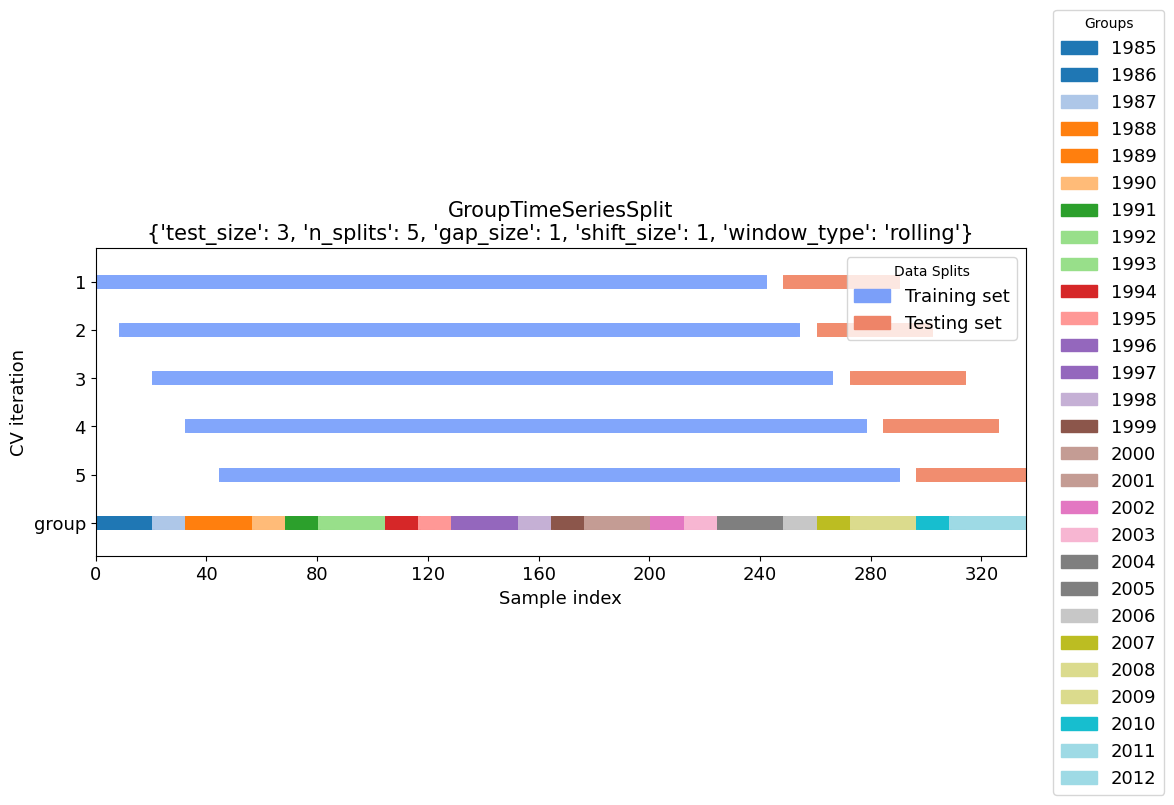


--- Детальная информация о разбиениях (mlxtend.print_split_info) ---
Train indices: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 22

In [21]:
# График: окна GroupTimeSeriesSplit (mlxtend)
print("\n--- Визуализация окон GTS-CV (mlxtend.plot_splits) ---")

plot_splits(X_train_val, y_train_val, groups=df_train_val['group_id'], **cv_args)

# Детальная информация по каждому разбиению (mlxtend)
print("\n--- Детальная информация о разбиениях (mlxtend.print_split_info) ---")

print_split_info(X_train_val, y_train_val, groups=df_train_val['group_id'], **cv_args)

### Финальная оценка


--- ФИНАЛЬНЫЙ РЕЗУЛЬТАТ НА OOT-ТЕСТЕ ---
Период OOT: 2013-01 - 2017-12
--------------------------------------------------
MAE: 7.77 | RMSE: 9.28 | R2: -0.001
--------------------------------------------------


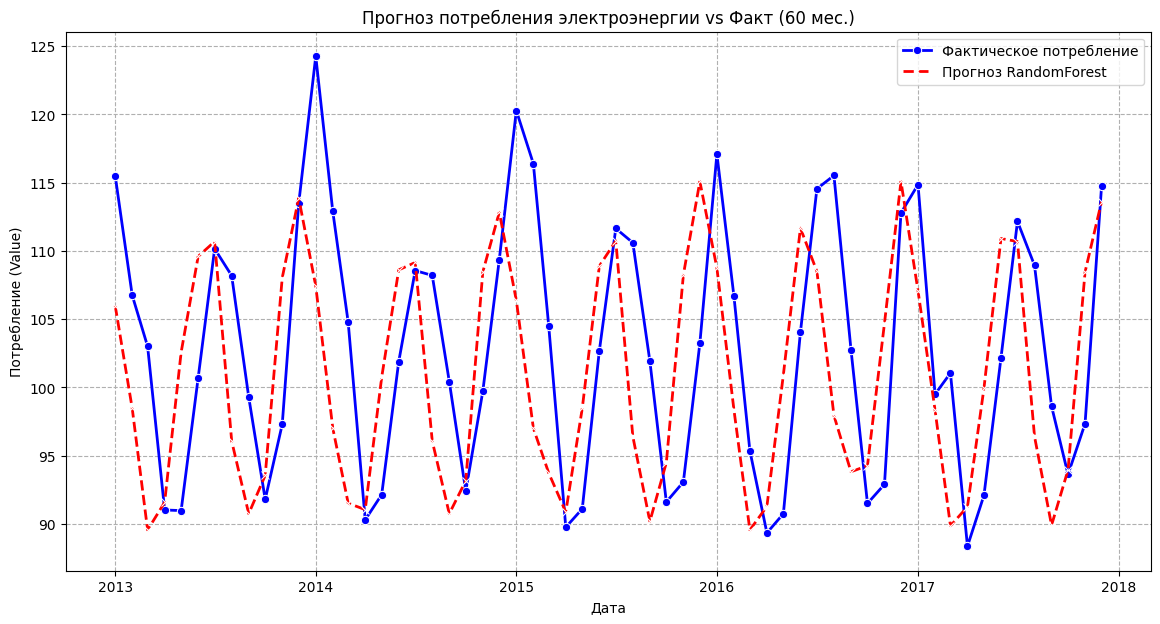

In [24]:
pipeline = Pipeline([
    ('regressor', RandomForestRegressor(n_estimators=10, random_state=42, n_jobs=-1))
])

# ----------------------------------------------------
# --- ФИНАЛЬНОЕ ОБУЧЕНИЕ И ПРОГНОЗ НА OOT ---
# ----------------------------------------------------

# 1. Создание фичей для финального обучения
df_train_final_engineered = create_time_series_features(df_train_val.copy())
feature_cols_final = [col for col in df_train_final_engineered.columns 
                      if col not in [MONTH_COL, TARGET_COL, FEATURE_COL, 'month_num', 'year', 'group_id']]

# Удаляем строки с NaN
df_train_final_engineered.dropna(subset=feature_cols_final, inplace=True)

X_train_final = df_train_final_engineered[feature_cols_final]
y_train_final = df_train_final_engineered[TARGET_COL]

pipeline.fit(X_train_final, y_train_final)

# 2. Подготовка OOT
# Используем историю для агрегатов
df_oot_full = pd.concat([df_train_val, df_oot_base], axis=0)
df_oot_full['month_num'] = df_oot_full[MONTH_COL].dt.month
df_oot_full['year'] = df_oot_full[MONTH_COL].dt.year

df_oot_full_engineered = create_time_series_features(df_oot_full)

# Берём только строки OOT
df_oot_engineered = df_oot_full_engineered.iloc[len(df_train_val):].copy()

X_oot_final = df_oot_engineered[feature_cols_final]
y_oot_final = df_oot_engineered['Value']

# 4. Прогноз и оценка OOT
y_pred_oot = pipeline.predict(X_oot_final)

mae_oot = mean_absolute_error(y_oot_final, y_pred_oot)
rmse_oot = np.sqrt(mean_squared_error(y_oot_final, y_pred_oot))
r2_oot = r2_score(y_oot_final, y_pred_oot)

print("\n--- ФИНАЛЬНЫЙ РЕЗУЛЬТАТ НА OOT-ТЕСТЕ ---")
print(f"Период OOT: {df_oot_base[MONTH_COL].iloc[0].strftime('%Y-%m')} - {df_oot_base[MONTH_COL].iloc[-1].strftime('%Y-%m')}")
print("-" * 50)
print(f"MAE: {mae_oot:.2f} | RMSE: {rmse_oot:.2f} | R2: {r2_oot:.3f}")
print("-" * 50)

# График: Фактический vs Прогнозируемый Временной ряд (OOT-тест)
plot_df_oot = pd.DataFrame({
    MONTH_COL: df_oot_base.loc[y_oot_final.index, MONTH_COL],
    'Actual': y_oot_final,
    'Predicted': y_pred_oot
})

plt.figure(figsize=(14, 7))
sns.lineplot(data=plot_df_oot, x=MONTH_COL, y='Actual', label='Фактическое потребление', marker='o', color='blue', linewidth=2)
sns.lineplot(data=plot_df_oot, x=MONTH_COL, y='Predicted', label='Прогноз RandomForest', marker='x', color='red', linestyle='--', linewidth=2)
plt.title(f'Прогноз потребления электроэнергии vs Факт ({len(y_oot_final)} мес.)')
plt.ylabel('Потребление (Value)')
plt.xlabel('Дата')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

